# Synthetic Data Validation — Gibson–Schwartz Monte Carlo Simulator

This notebook generates one synthetic dataset from the GS Monte Carlo simulator
and **visually validates** it before it is used to benchmark the PINN inversion.

**Why this simulator exists.** The convenience yield $\delta_t$ is *latent* —
unobservable from market data — so there is no ground truth to score an
inversion against. The simulator builds data from *known* parameters and a
*stored true* $\delta_t$ path, which becomes the evaluation target. The true
$\delta_t$ is sacred: retained for scoring, **never** fed to the inversion.

**Architecture (Option A).** Simulate physical-measure ($\mathbb{P}$) state
paths → price the futures panel with the closed-form risk-neutral ($\mathbb{Q}$)
pricer → add measurement noise. The closed form gives *exact* prices given the
state, so signal-to-noise is a single controllable dial in the observation
layer (no nested-Monte-Carlo pricing error).

Pipeline: `data.paths` (ℙ paths) → `physics.gibson_schwartz` (ℚ pricing) →
`data.observe` (noisy panel), tied together by `data.generate`.

In [1]:
# float64 is REQUIRED. The GS closed form is verified by a PDE residual that
# floors at ~1e-5 in float32 but drops to ~1e-14 in float64 — only in double
# precision does the simulator confirm its own analytic coefficients
# (see CLAUDE.md §5). Enable it BEFORE any JAX array is created.
import jax
jax.config.update("jax_enable_x64", True)

import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

from gs_wamol.data.generate import generate
from gs_wamol.data.paths import simulate_paths
from gs_wamol.physics.gibson_schwartz import futures, term_structure

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "axes.axisbelow": True, "font.size": 10})

## 1. Generate a dataset

`generate(seed=0)` runs the full pipeline and returns a dict. We unpack it with
explicit shapes — the vocabulary **P = paths, N = dates, M = maturities** is
used throughout.

In [2]:
data = generate(seed=0)

S          = np.asarray(data["S"])            # (P, N)    spot price paths
delta_true = np.asarray(data["delta_true"])   # (P, N)    GROUND-TRUTH latent CY
logF_clean = np.asarray(data["log_F_clean"])  # (P, N, M) exact log-futures
logF_obs   = np.asarray(data["log_F_obs"])    # (P, N, M) noisy log-futures
t          = np.asarray(data["t_grid"])       # (N,)      time grid, years
taus       = np.asarray(data["taus"])         # (M,)      maturities, years
P, N       = S.shape
M          = taus.shape[0]

pP, pQ = data["params_P"], data["params_Q"]   # ℙ (simulate) and ℚ (price) params
print(f"paths P      : {P}")
print(f"dates N      : {N}   ({t[0]:.0f}..{t[-1]:.0f} yrs, dt={t[1]-t[0]:.4f}y)")
print(f"maturities M : {M}   {np.round(taus, 3)}")
print(f"panel shape  : {logF_obs.shape}  (P, N, M)")
print(f"alpha_P={pP.alpha_P:.4f}  ->  alpha_Q={pQ.alpha_Q:.4f}   "
      f"(shift = -sigma2*lambda2/kappa, lambda2={data['lambda2']})")

W0623 00:44:03.696377 7848563 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


paths P      : 64
dates N      : 2521   (0..10 yrs, dt=0.0040y)
maturities M : 12   [0.083 0.167 0.25  0.333 0.417 0.5   0.583 0.667 0.75  0.833 0.917 1.   ]
panel shape  : (64, 2521, 12)  (P, N, M)
alpha_P=0.1500  ->  alpha_Q=0.1233   (shift = -sigma2*lambda2/kappa, lambda2=0.1)


## 2. Spot price paths $S_t$ (physical measure ℙ)

Simulated in log-space then exponentiated, so $S_t>0$ by construction. The drift
is $(\mu-\delta_t)$: the convenience yield acts like a dividend carry, pulling
the spot's growth rate below $\mu$. We plot 12 of the 64 paths — all of them
would just be visual noise.

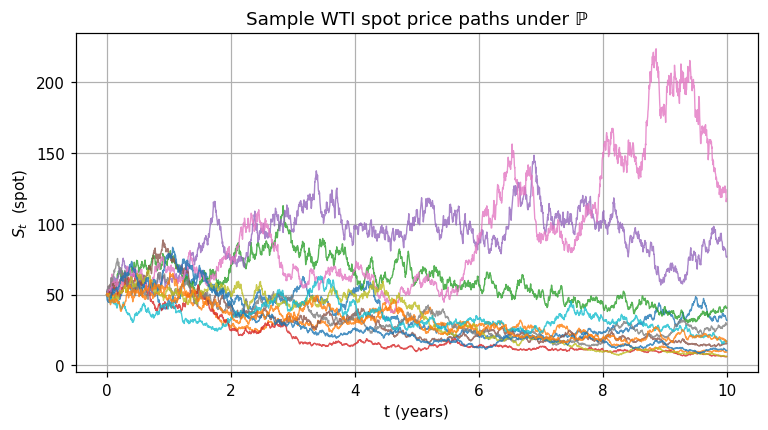

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(12):
    ax.plot(t, S[i], lw=0.9, alpha=0.8)
ax.set_xlabel("t (years)"); ax.set_ylabel(r"$S_t$  (spot)")
ax.set_title("Sample WTI spot price paths under ℙ")
plt.show()

## 3. The latent convenience yield $\delta_t$ — the inversion target

These are the paths the PINN must recover **from prices alone**. $\delta_t$ is an
Ornstein–Uhlenbeck process *(mean-reverting Gaussian)*:
$d\delta = \kappa(\alpha^{\mathbb{P}}-\delta)\,dt + \sigma_2\,dW$.
This dataset starts at $\delta_0=\alpha^{\mathbb{P}}$, so the ensemble *mean*
sits at $\alpha^{\mathbb{P}}$ while the *variance* fans out toward the stationary
level $\sigma_2^2/2\kappa$.

> **Reminder:** `delta_true` is shown here only because *we* are the data
> generator. It must never enter the inversion.

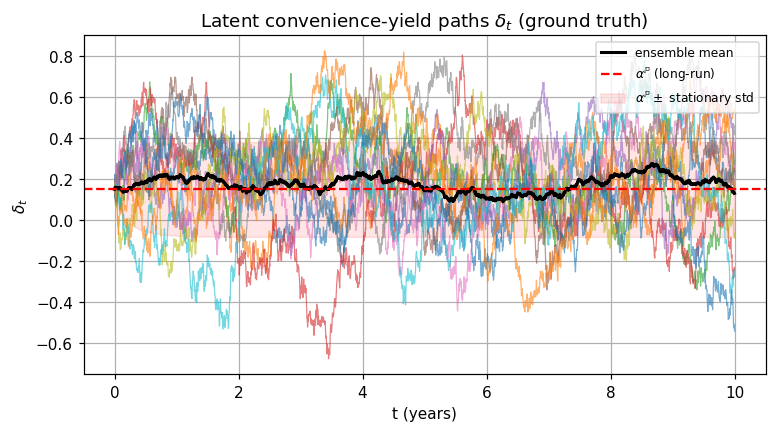

In [4]:
kappa, sig2, aP = pP.kappa, pP.sigma2, pP.alpha_P
# Time-dependent OU std: sqrt( sigma2^2/(2k) * (1 - e^{-2k t}) ).
ou_std = np.sqrt(sig2**2 / (2*kappa) * (1 - np.exp(-2*kappa*t)))

fig, ax = plt.subplots(figsize=(8, 4))
for i in range(12):
    ax.plot(t, delta_true[i], lw=0.8, alpha=0.6)
ax.plot(t, delta_true.mean(0), "k-", lw=2, label="ensemble mean")
ax.axhline(aP, color="r", ls="--", lw=1.5, label=r"$\alpha^{\mathbb{P}}$ (long-run)")
ax.fill_between(t, aP - ou_std, aP + ou_std, color="r", alpha=0.10,
                label=r"$\alpha^{\mathbb{P}}\pm$ stationary std")
ax.set_xlabel("t (years)"); ax.set_ylabel(r"$\delta_t$")
ax.set_title(r"Latent convenience-yield paths $\delta_t$ (ground truth)")
ax.legend(loc="upper right", fontsize=8)
plt.show()

## 4. Mean-reversion check — does $\delta_t$ match the theory?

To actually *see* reversion, start a fresh ensemble **away** from the long-run
level ($\delta_0=-0.10$) and watch the mean drift back to $\alpha^{\mathbb{P}}$
at rate $\kappa$. The characteristic timescale is $\tau^\*=1/\kappa$ — also the
identifiability-critical timescale for the inversion. We overlay the analytic OU
mean $\alpha^{\mathbb{P}}+(\delta_0-\alpha^{\mathbb{P}})e^{-\kappa t}$.

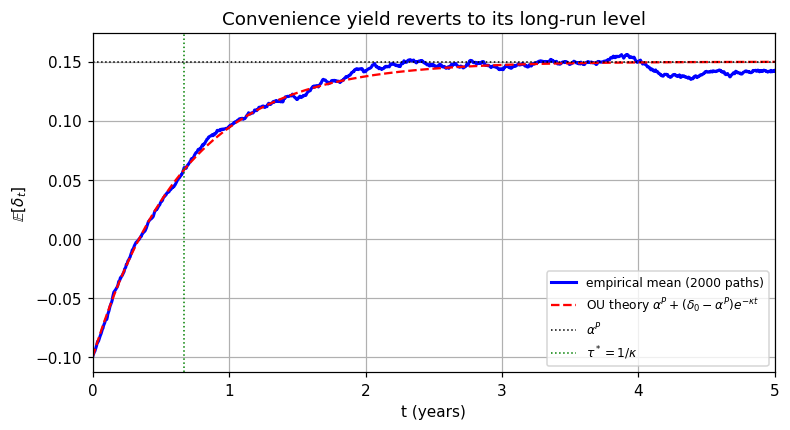

In [5]:
delta0 = -0.10
t2, _, dpaths = simulate_paths(jax.random.PRNGKey(7), pP, S0=50.0, delta0=delta0,
                               T=10.0, n_steps=2520, n_paths=2000)
t2, dpaths = np.asarray(t2), np.asarray(dpaths)          # (N,), (2000, N)

emp_mean  = dpaths.mean(0)
theo_mean = aP + (delta0 - aP) * np.exp(-kappa*t2)        # OU mean
tau_star  = 1.0 / kappa

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t2, emp_mean, "b-", lw=2, label="empirical mean (2000 paths)")
ax.plot(t2, theo_mean, "r--", lw=1.5,
        label=r"OU theory $\alpha^P+(\delta_0-\alpha^P)e^{-\kappa t}$")
ax.axhline(aP, color="k", ls=":", lw=1, label=r"$\alpha^P$")
ax.axvline(tau_star, color="g", ls=":", lw=1, label=r"$\tau^*=1/\kappa$")
ax.set_xlim(0, 5)
ax.set_xlabel("t (years)"); ax.set_ylabel(r"$\mathbb{E}[\delta_t]$")
ax.set_title("Convenience yield reverts to its long-run level")
ax.legend(fontsize=8)
plt.show()

### Terminal distribution vs the stationary law
At large $t$ the OU process is Gaussian with mean $\alpha^{\mathbb{P}}$ and
variance $\sigma_2^2/2\kappa$. The terminal sample $\delta_T$ should match it.

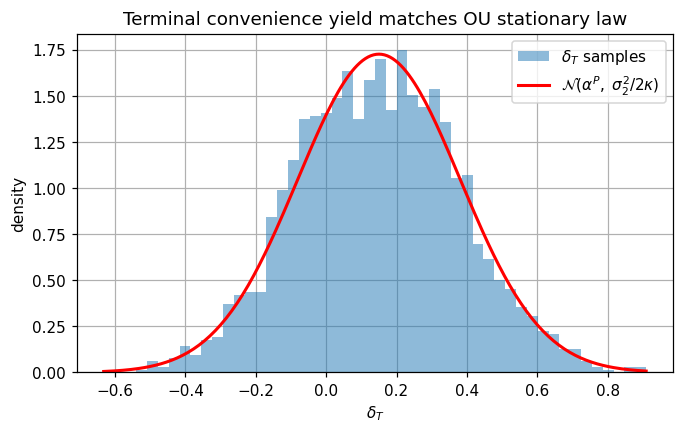

empirical mean/std : 0.1468 / 0.2319
theoretical        : 0.1500 / 0.2309


In [6]:
dT  = dpaths[:, -1]
m_T = aP + (delta0 - aP) * np.exp(-kappa*t2[-1])
s_T = np.sqrt(sig2**2 / (2*kappa) * (1 - np.exp(-2*kappa*t2[-1])))
xs  = np.linspace(dT.min(), dT.max(), 200)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dT, bins=50, density=True, alpha=0.5, label=r"$\delta_T$ samples")
ax.plot(xs, norm.pdf(xs, m_T, s_T), "r-", lw=2,
        label=r"$\mathcal{N}(\alpha^P,\ \sigma_2^2/2\kappa)$")
ax.set_xlabel(r"$\delta_T$"); ax.set_ylabel("density")
ax.set_title("Terminal convenience yield matches OU stationary law")
ax.legend()
plt.show()
print(f"empirical mean/std : {dT.mean():.4f} / {dT.std():.4f}")
print(f"theoretical        : {m_T:.4f} / {s_T:.4f}")

## 5. Futures term structure — backwardation vs contango

The closed form is $\ln\hat F(\tau,S,\delta)=\ln S + B(\tau)\delta + A(\tau)$
with $B(\tau)=-(1-e^{-\kappa\tau})/\kappa<0$. Because $B<0$:

* **high** convenience yield → curve tilts **down** (*backwardation*, near
  months pricier),
* **low** yield → curve tilts **up** (*contango*).

All curves anchor at the spot $S$ as $\tau\to0$ since $\hat F(0,S,\delta)=S$.
Markers are the 12 discrete liquid maturities actually sampled into the panel.

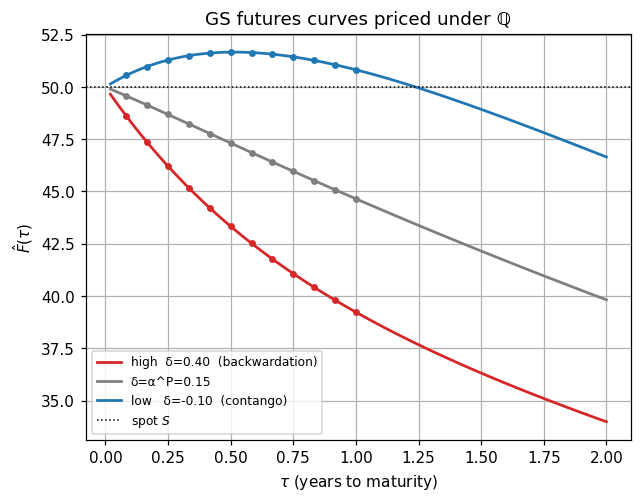

In [7]:
S_ref = 50.0
tau_grid = np.linspace(0.02, 2.0, 100)
for d_val, lab, c in [(0.40,  "high  δ=0.40  (backwardation)", "C3"),
                      (aP,    f"δ=α^P={aP:.2f}",               "C7"),
                      (-0.10, "low   δ=-0.10  (contango)",     "C0")]:
    curve = np.asarray(term_structure(jnp.asarray(tau_grid), S_ref, d_val, pQ))
    plt.plot(tau_grid, curve, color=c, lw=1.8, label=lab)
    pts = np.asarray(term_structure(jnp.asarray(taus), S_ref, d_val, pQ))
    plt.plot(taus, pts, ".", color=c, ms=7)         # the M sampled maturities
plt.axhline(S_ref, color="k", ls=":", lw=1, label="spot $S$")
plt.xlabel(r"$\tau$ (years to maturity)"); plt.ylabel(r"$\hat F(\tau)$")
plt.title("GS futures curves priced under ℚ")
plt.legend(fontsize=8)
plt.show()

## 6. The observation layer — clean vs noisy

Real quotes carry bid–ask spread, non-simultaneity and data error. We model
these as additive Gaussian noise in *log-price* space with std `noise_std`
(here 0.5%). This is the single signal-to-noise dial; the pricer itself stays
exact. Left: one contract over time. Right: the full residual panel vs the
target $\mathcal{N}(0,\text{noise\_std})$.

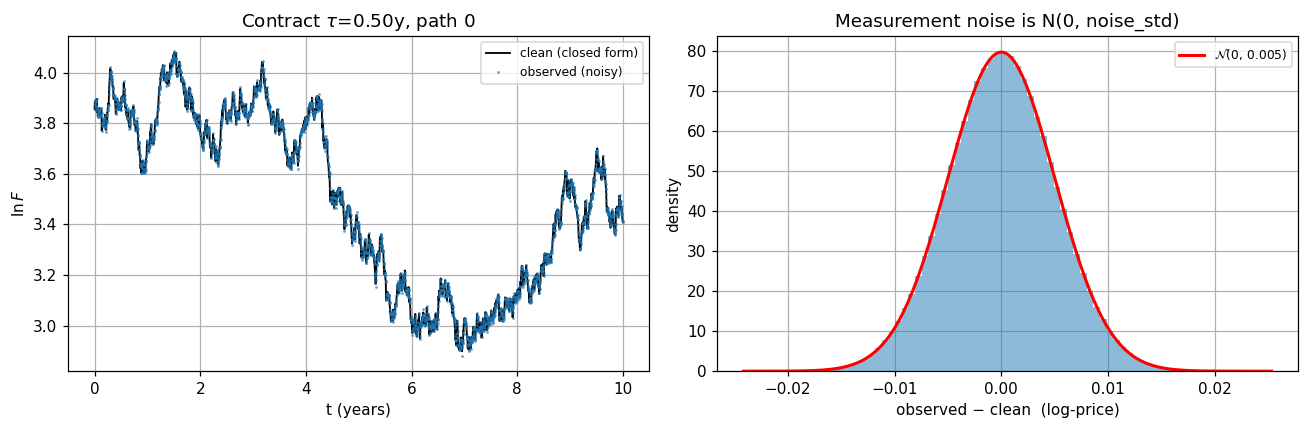

residual std = 0.00500  (target noise_std = 0.005)


In [8]:
m, p = 5, 0   # ~6-month contract (taus[5]), path 0
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(t, logF_clean[p, :, m], "k-", lw=1.2, label="clean (closed form)")
ax[0].plot(t, logF_obs[p, :, m], "C0.", ms=2, alpha=0.5, label="observed (noisy)")
ax[0].set_xlabel("t (years)"); ax[0].set_ylabel(r"$\ln F$")
ax[0].set_title(fr"Contract $\tau$={taus[m]:.2f}y, path {p}")
ax[0].legend(fontsize=8)

resid = (logF_obs - logF_clean).ravel()
xs = np.linspace(resid.min(), resid.max(), 200)
ax[1].hist(resid, bins=80, density=True, alpha=0.5)
ax[1].plot(xs, norm.pdf(xs, 0, 0.005), "r-", lw=2, label=r"$\mathcal{N}(0,\,0.005)$")
ax[1].set_xlabel("observed − clean  (log-price)"); ax[1].set_ylabel("density")
ax[1].set_title("Measurement noise is N(0, noise_std)")
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()
print(f"residual std = {resid.std():.5f}  (target noise_std = 0.005)")

## 7. Numerical self-consistency (float64)

Two cheap analytic guards (the full four-check harness lives in
`tests/test_synthetic_gs.py`):

1. **Initial condition** $\hat F(0,S,\delta)=S$.
2. **PDE residual** — substitute the closed form into GS-PDE-$\tau$ via autodiff;
   it must vanish to machine epsilon, the definitive confirmation that
   $A(\tau),B(\tau)$ are exact. (This is also why float64 matters: in float32
   this would floor at ~$10^{-5}$.)

In [9]:
k1, k2, k3 = jax.random.split(jax.random.PRNGKey(0), 3)
Ss = jax.random.uniform(k1, (2000,), minval=10.,  maxval=120.)
ds = jax.random.uniform(k2, (2000,), minval=-0.3, maxval=0.5)
ts = jax.random.uniform(k3, (2000,), minval=1e-3, maxval=2.0)

# [1] initial condition: F(0, S, delta) == S
ic = float(jnp.max(jnp.abs(futures(jnp.zeros_like(Ss), Ss, ds, pQ) - Ss)))

# [2] PDE residual via autodiff (GS-PDE-tau)
F    = lambda tau, s, d: futures(tau, s, d, pQ)
F_t  = jax.vmap(jax.grad(F, 0))(ts, Ss, ds)
F_s  = jax.vmap(jax.grad(F, 1))(ts, Ss, ds)
F_d  = jax.vmap(jax.grad(F, 2))(ts, Ss, ds)
F_ss = jax.vmap(jax.grad(jax.grad(F, 1), 1))(ts, Ss, ds)
F_dd = jax.vmap(jax.grad(jax.grad(F, 2), 2))(ts, Ss, ds)
F_sd = jax.vmap(jax.grad(jax.grad(F, 1), 2))(ts, Ss, ds)
rhs = ((pQ.r - ds)*Ss*F_s + pQ.kappa*(pQ.alpha_Q - ds)*F_d
       + 0.5*pQ.sigma1**2*Ss**2*F_ss
       + pQ.rho*pQ.sigma1*pQ.sigma2*Ss*F_sd
       + 0.5*pQ.sigma2**2*F_dd)
res = float(jnp.max(jnp.abs(F_t - rhs)))

print(f"[1] max|F(0,S,d) - S|    = {ic:.2e}   {'PASS' if ic < 1e-10 else 'FAIL'}")
print(f"[2] max|F_tau - RHS(PDE)| = {res:.2e}   {'PASS' if res < 1e-10 else 'FAIL'}")

[1] max|F(0,S,d) - S|    = 5.68e-14   PASS
[2] max|F_tau - RHS(PDE)| = 1.38e-14   PASS
